In [1]:
import glob
import logging
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd

from mlb_edge_finder import config
from mlb_edge_finder.backtest import compute_summary, run_backtest
from mlb_edge_finder.model import load_model
from mlb_edge_finder.training_data import load_training_set

config.setup_logging()

In [2]:
model_files = sorted(glob.glob(str(config.MODELS_DIR / "xgb_*.pkl")))
if not model_files:
    raise FileNotFoundError("No saved model found. Run training cells in 01_exploration.ipynb first.")

latest_model_path = model_files[-1]
model_date_str = latest_model_path.split("xgb_")[-1].replace(".pkl", "")
model_date = date.fromisoformat(model_date_str)

print(f"Loading model: {latest_model_path}")
clf = load_model(model_date)

SEASONS = [2019, 2021, 2022, 2023, 2024, 2025]
training_df = load_training_set(SEASONS)
print(f"Training data: {len(training_df):,} games across {SEASONS}")

Loading model: /Users/jaydengould/Documents/projects/mlb-edge-finder/models/xgb_2026-05-12.pkl
Training data: 15,050 games across [2019, 2021, 2022, 2023, 2024, 2025]


In [3]:
# Synthetic market odds: -110/-110 (50/50 market, 4.76% vig)
# Tests whether model outperforms naive even-money pricing.
# Real bookmaker lines vary — this is a lower bound on real-world profitability.
backtest_df = run_backtest(clf, training_df, home_market_prob=0.5, vig=0.0476, unit=100)
print(f"Bets placed: {len(backtest_df)}")
backtest_df.head(10)

2026-05-24 22:08:48,924 | INFO | mlb_edge_finder.backtest | Backtest complete: 292 bets across 3010 test games (EV=50% edge=30%)


Bets placed: 292


,game_date,home_name,away_name,bet_side,american_odds,model_prob,ev,kelly_fraction,actual_home_win,won,pnl,cumulative_pnl
0,2019-03-28,Toronto Blue Jays,Detroit Tigers,home,-110,0.8731,0.6667,0.3667,0,False,-100.000000,-100.000000
1,2019-03-30,Kansas City Royals,Chicago White Sox,away,-110,0.8373,0.5985,0.3292,1,False,-100.000000,-200.000000
2,2019-04-03,Atlanta Braves,Chicago Cubs,home,-110,0.8438,0.6109,0.3360,1,True,90.909091,-109.090909
3,2019-04-07,San Francisco Giants,Tampa Bay Rays,away,-110,0.8404,0.6045,0.3325,0,True,90.909091,-18.181818
4,2019-04-09,Houston Astros,New York Yankees,home,-110,0.8969,0.7123,0.3918,1,True,90.909091,72.727273
5,2019-04-20,Baltimore Orioles,Minnesota Twins,away,-110,0.9641,0.8405,0.4623,0,True,90.909091,163.636364
6,2019-04-20,Baltimore Orioles,Minnesota Twins,away,-110,0.9787,0.8685,0.4777,0,True,90.909091,254.545455
7,2019-04-21,Texas Rangers,Houston Astros,away,-110,0.8422,0.6079,0.3344,1,False,-100.000000,154.545455
8,2019-04-22,Colorado Rockies,Washington Nationals,away,-110,0.9280,0.7716,0.4244,1,False,-100.000000,54.545455
9,2019-04-28,Los Angeles Dodgers,Pittsburgh Pirates,home,-110,0.8251,0.5752,0.3163,1,True,90.909091,145.454545


In [4]:
summary = compute_summary(backtest_df, unit=100.0)

print("=" * 40)
print("BACKTEST SUMMARY")
print("=" * 40)
print(f"  Bets placed  : {summary['n_bets']}")
print(f"  Wins         : {summary['n_wins']}")
print(f"  Win rate     : {summary['win_rate']:.1%}")
print(f"  Total P&L    : ${summary['total_pnl']:+,.2f}")
print(f"  ROI          : {summary['roi_pct']:+.2f}%")
print(f"  Avg EV       : {summary['avg_ev']:.2%}")
print(f"  Max drawdown : ${summary['max_drawdown']:,.2f}")
print(f"  Sharpe ratio : {summary['sharpe_ratio']:.3f} (per-bet, not annualised)")
print("=" * 40)
print()
print("Assumptions:")
print("  - Market odds: -110 / -110 (50/50 even market, 4.76% vig)")
print("  - Bet size: $100 flat per flagged edge")
print("  - Test set: held-out 20% (stratified random split, same as model evaluation)")
print("  - Lookahead note: end-of-season team stats used for all games in each season")

BACKTEST SUMMARY
  Bets placed  : 292
  Wins         : 237
  Win rate     : 81.2%
  Total P&L    : $+16,045.45
  ROI          : +54.95%
  Avg EV       : 69.37%
  Max drawdown : $400.00
  Sharpe ratio : 0.735 (per-bet, not annualised)

Assumptions:
  - Market odds: -110 / -110 (50/50 even market, 4.76% vig)
  - Bet size: $100 flat per flagged edge
  - Test set: held-out 20% (stratified random split, same as model evaluation)
  - Lookahead note: end-of-season team stats used for all games in each season


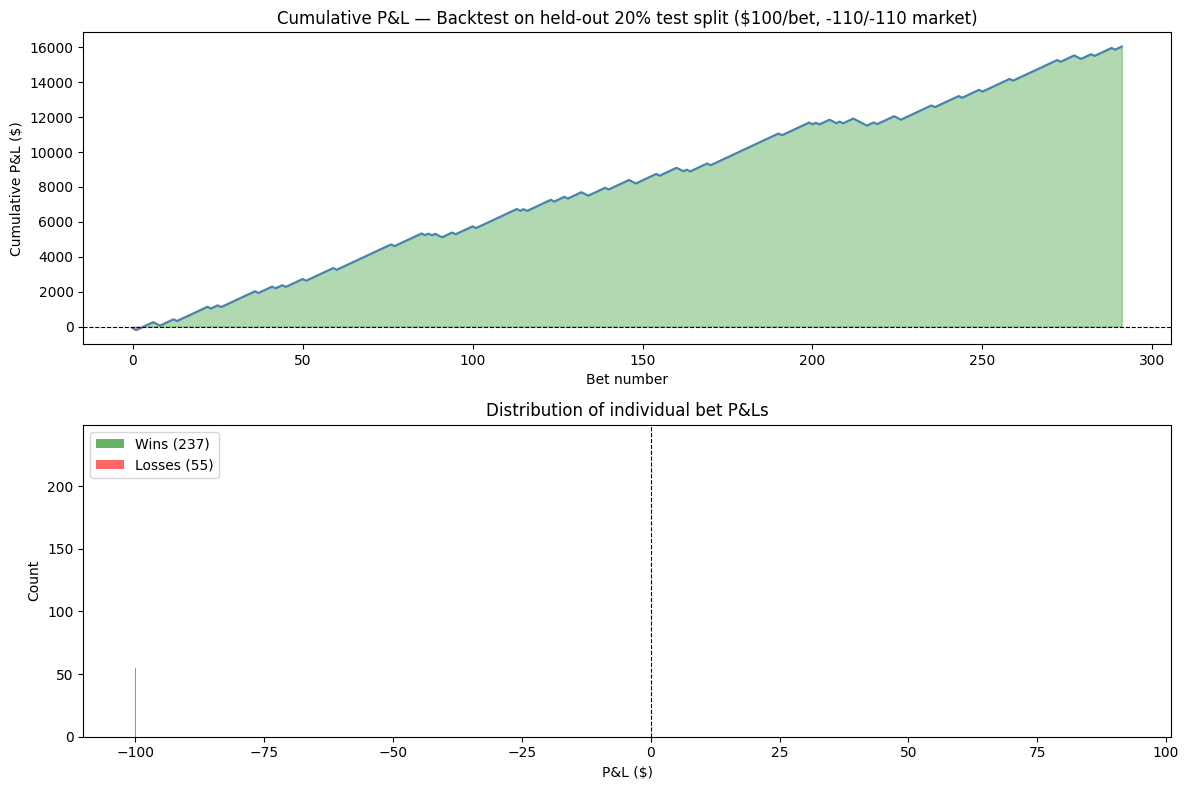

Plot saved to /Users/jaydengould/Documents/projects/mlb-edge-finder/notebooks/backtest_pnl.png


In [5]:
if backtest_df.empty:
    print("No bets found — model did not outperform the even-money market at the 5% EV threshold.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    axes[0].plot(backtest_df.index, backtest_df["cumulative_pnl"], color="steelblue", linewidth=1.5)
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].fill_between(
        backtest_df.index, backtest_df["cumulative_pnl"], 0,
        where=backtest_df["cumulative_pnl"] >= 0, alpha=0.3, color="green",
    )
    axes[0].fill_between(
        backtest_df.index, backtest_df["cumulative_pnl"], 0,
        where=backtest_df["cumulative_pnl"] < 0, alpha=0.3, color="red",
    )
    axes[0].set_title("Cumulative P&L — Backtest on held-out 20% test split ($100/bet, -110/-110 market)")
    axes[0].set_xlabel("Bet number")
    axes[0].set_ylabel("Cumulative P&L ($)")

    wins = backtest_df[backtest_df["won"]]["pnl"]
    losses = backtest_df[~backtest_df["won"]]["pnl"]
    axes[1].hist(wins, bins=20, color="green", alpha=0.6, label=f"Wins ({len(wins)})")
    axes[1].hist(losses, bins=20, color="red", alpha=0.6, label=f"Losses ({len(losses)})")
    axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Distribution of individual bet P&Ls")
    axes[1].set_xlabel("P&L ($)")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    _plot_path = config.MODELS_DIR.parent / "notebooks" / "backtest_pnl.png"
    plt.savefig(_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {_plot_path}")

## Threshold Sweep — Finding Sharpe-Optimal Filters

Sweeps EV threshold (5%–50%) × MIN_PROB_EDGE (0%–30%) over the synthetic backtest to find the combination with the best risk-adjusted return (Sharpe ratio).

In [6]:
from mlb_edge_finder.backtest import sweep_thresholds

sweep_results = sweep_thresholds(clf, training_df)
print("Top 10 threshold combinations by Sharpe ratio:")
print(sweep_results.head(10).to_string(index=False))

best = sweep_results.iloc[0]
print(f"\nOptimal: EV_THRESHOLD={best['ev_threshold']:.0%}  "
      f"MIN_PROB_EDGE={best['min_prob_edge']:.0%}  "
      f"Sharpe={best['sharpe_ratio']:.3f}  "
      f"Bets/day={best['avg_bets_per_day']:.1f}")

2026-05-24 22:08:49,202 | INFO | mlb_edge_finder.backtest | Starting threshold sweep: 70 combinations


2026-05-24 22:08:49,245 | INFO | mlb_edge_finder.backtest | Backtest complete: 2370 bets across 3010 test games (EV=5% edge=0%)


2026-05-24 22:08:49,285 | INFO | mlb_edge_finder.backtest | Backtest complete: 2057 bets across 3010 test games (EV=5% edge=5%)


2026-05-24 22:08:49,322 | INFO | mlb_edge_finder.backtest | Backtest complete: 1511 bets across 3010 test games (EV=5% edge=10%)


2026-05-24 22:08:49,356 | INFO | mlb_edge_finder.backtest | Backtest complete: 1068 bets across 3010 test games (EV=5% edge=15%)


...

2026-05-24 22:08:51,493 | INFO | mlb_edge_finder.backtest | Backtest complete: 425 bets across 3010 test games (EV=50% edge=20%)


2026-05-24 22:08:51,525 | INFO | mlb_edge_finder.backtest | Backtest complete: 425 bets across 3010 test games (EV=50% edge=25%)


2026-05-24 22:08:51,555 | INFO | mlb_edge_finder.backtest | Backtest complete: 292 bets across 3010 test games (EV=50% edge=30%)


2026-05-24 22:08:51,557 | INFO | mlb_edge_finder.backtest | Optimal: EV=50% MIN_PROB_EDGE=30% Sharpe=0.735 (292 bets, 1.3/day)


Top 10 threshold combinations by Sharpe ratio:
 ev_threshold  min_prob_edge  n_bets  win_rate  roi_pct  sharpe_ratio  avg_bets_per_day
         0.50            0.3     292    0.8116    54.95        0.7349              1.29
         0.10            0.3     292    0.8116    54.95        0.7349              1.29
         0.20            0.3     292    0.8116    54.95        0.7349              1.29
         0.15            0.3     292    0.8116    54.95        0.7349              1.29
         0.25            0.3     292    0.8116    54.95        0.7349              1.29
         0.35            0.3     292    0.8116    54.95        0.7349              1.29
         0.45            0.3     292    0.8116    54.95        0.7349              1.29
         0.40            0.3     292    0.8116    54.95        0.7349              1.29
         0.05            0.3     292    0.8116    54.95        0.7349              1.29
         0.30            0.3     292    0.8116    54.95        0.7349    

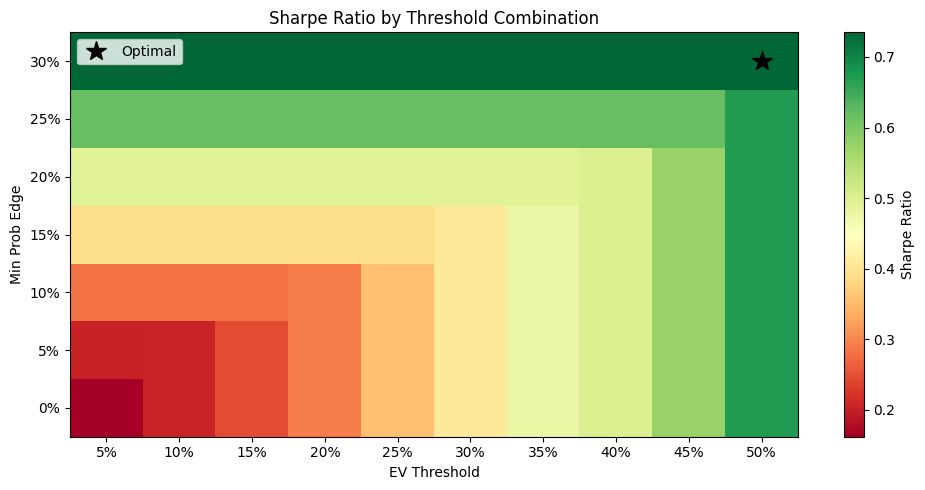

Saved: threshold_heatmap.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

pivot = sweep_results.pivot(index="min_prob_edge", columns="ev_threshold", values="sharpe_ratio")

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap="RdYlGn")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{v:.0%}" for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{v:.0%}" for v in pivot.index])
ax.set_xlabel("EV Threshold")
ax.set_ylabel("Min Prob Edge")
ax.set_title("Sharpe Ratio by Threshold Combination")
plt.colorbar(im, ax=ax, label="Sharpe Ratio")

best_ev_idx = list(pivot.columns).index(best["ev_threshold"])
best_edge_idx = list(pivot.index).index(best["min_prob_edge"])
ax.plot(best_ev_idx, best_edge_idx, "k*", markersize=15, label="Optimal")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_heatmap.png", dpi=150)
plt.show()
print("Saved: threshold_heatmap.png")

2026-05-24 22:08:51,794 | INFO | mlb_edge_finder.backtest | Backtest complete: 292 bets across 3010 test games (EV=50% edge=30%)


=== Optimal-threshold backtest (held-out 20% test split) ===
  n_bets              : 292
  n_wins              : 237
  win_rate            : 0.8116
  total_pnl           : 16045.45
  roi_pct             : 54.95
  avg_ev              : 0.6937
  max_drawdown        : 400.0
  sharpe_ratio        : 0.7349


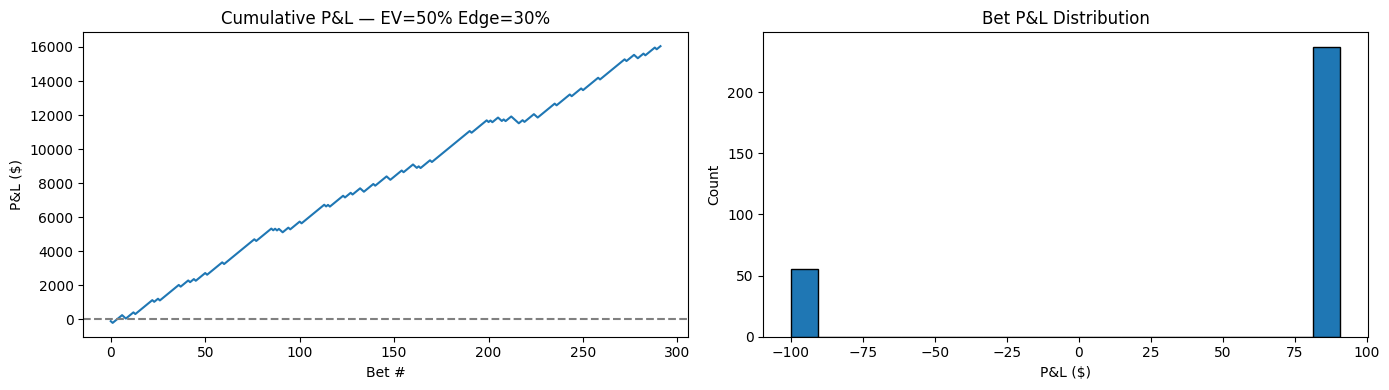

Saved: backtest_optimal_pnl.png


In [8]:
from mlb_edge_finder.backtest import run_backtest, compute_summary

bt_optimal = run_backtest(
    clf, training_df,
    ev_threshold=best["ev_threshold"],
    min_prob_edge=best["min_prob_edge"],
)

summary_optimal = compute_summary(bt_optimal)
print("=== Optimal-threshold backtest (held-out 20% test split) ===")
for k, v in summary_optimal.items():
    print(f"  {k:20s}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(bt_optimal["cumulative_pnl"].values)
axes[0].set_title(f"Cumulative P&L — EV={best['ev_threshold']:.0%} Edge={best['min_prob_edge']:.0%}")
axes[0].set_xlabel("Bet #")
axes[0].set_ylabel("P&L ($)")
axes[0].axhline(0, color="gray", linestyle="--")

axes[1].hist(bt_optimal["pnl"], bins=20, edgecolor="black")
axes[1].set_title("Bet P&L Distribution")
axes[1].set_xlabel("P&L ($)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("backtest_optimal_pnl.png", dpi=150)
plt.show()
print("Saved: backtest_optimal_pnl.png")